# Trust Region Policy Optimization (TRPO)

**A hands-on tutorial with theory and PyTorch implementation**

---

Policy gradient methods before 2015 had a dirty secret: they were fragile. Take a step that is slightly too large and
the policy collapses; because the next batch of data is collected *by the collapsed policy*, it may never recover. The
learning rate had to be tuned per task, and even then training curves were full of cliffs.

**TRPO** ([Schulman et al., 2015](https://arxiv.org/abs/1502.05477)) fixed this with a principled answer: at every
iteration, take the *largest* step that improves a surrogate objective while keeping the new policy within a fixed
**KL-divergence trust region** of the old one. Backed by a monotonic improvement theorem, TRPO trained neural-network
policies on simulated locomotion (MuJoCo) and Atari with a *single* set of hyperparameters — the first time a policy
gradient method was that robust. It is the direct parent of PPO, which replaced its second-order machinery with
clipping; understanding TRPO is understanding what PPO is approximating.

## What you will learn

1. The **policy improvement bound** and why it justifies a KL-constrained surrogate.
2. The **natural policy gradient** and the role of the Fisher information matrix.
3. How TRPO solves the constrained problem: **conjugate gradient**, **Fisher-vector products**, and **line search**.
4. A **from-scratch PyTorch implementation** on `CartPole-v1` with all three pieces.
5. Why PPO replaced TRPO in practice, and what was lost.

## Notebook outline

1. The problem with policy gradient steps
2. The surrogate objective and the improvement bound
3. The natural gradient
4. Solving the trust-region problem
5. Implementation
6. Training and diagnostics
7. **Visual demonstration** of the trained agent
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

In [4]:
def moving_average(x, w=20):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

## 1. The Problem with Policy Gradient Steps

Gradient ascent, $\theta \leftarrow \theta + \alpha \nabla_\theta J$, takes a step of fixed size $\alpha$ in
**parameter space**. But the effect on the **policy** is wildly non-uniform: the same $\Delta\theta$ can leave
$\pi_\theta$ almost unchanged in one region of parameter space and flip it entirely in another (think of a softmax
with large logits versus small ones). What we actually want to control is how much the *distribution over actions*
changes, i.e. a step of fixed size in **policy space**, measured by something like the KL divergence
$D_{\mathrm{KL}}(\pi_{\theta_{\text{old}}} \,\|\, \pi_\theta)$.

TRPO makes this precise: find the update that maximizes expected improvement **subject to** the average KL divergence
between old and new policies being at most $\delta$.

## 2. The Surrogate Objective and the Improvement Bound

### 2.1 Performance difference lemma

Kakade & Langford (2002) showed that the improvement of any policy $\pi$ over $\pi_{\text{old}}$ can be written *exactly*
in terms of the old policy's advantage function:

$$
J(\pi) - J(\pi_{\text{old}}) \;=\; \mathbb{E}_{s \sim d^{\pi},\, a \sim \pi}\big[A^{\pi_{\text{old}}}(s, a)\big],
$$

where $d^{\pi}$ is the (discounted) state visitation distribution *of the new policy*. That is the catch: we have samples
from $d^{\pi_{\text{old}}}$, not $d^{\pi}$.

### 2.2 The surrogate

TRPO approximates $d^{\pi} \approx d^{\pi_{\text{old}}}$ and uses importance sampling over actions:

$$
L_{\theta_{\text{old}}}(\theta) \;=\; \mathbb{E}_{s \sim d^{\pi_{\text{old}}},\, a \sim \pi_{\text{old}}}\!\left[\frac{\pi_\theta(a|s)}{\pi_{\theta_{\text{old}}}(a|s)}\, A^{\pi_{\text{old}}}(s,a)\right].
$$

$L$ matches $J$ to first order at $\theta_{\text{old}}$ (same value, same gradient), so for small steps maximizing $L$
improves $J$.

### 2.3 The monotonic improvement bound

The paper's main theorem quantifies "small": with $D^{\max}_{\mathrm{KL}}(\pi_{\text{old}}, \pi) = \max_s D_{\mathrm{KL}}(\pi_{\text{old}}(\cdot|s)\,\|\,\pi(\cdot|s))$,

$$
J(\pi) \;\ge\; L_{\pi_{\text{old}}}(\pi) \;-\; C\, D^{\max}_{\mathrm{KL}}(\pi_{\text{old}}, \pi), \qquad C = \frac{4 \epsilon \gamma}{(1-\gamma)^2},\ \ \epsilon = \max_{s,a}|A^{\pi_{\text{old}}}(s,a)|.
$$

Maximizing the right-hand side (a *minorization–maximization* scheme) guarantees monotonic improvement. In practice
$C$ is far too conservative, and the max-KL is not estimable, so TRPO makes two practical substitutions: use the
**mean** KL over sampled states, and turn the penalty into a **hard constraint** with a tunable radius $\delta$:

$$
\boxed{\;\max_\theta\; L_{\theta_{\text{old}}}(\theta) \quad \text{s.t.} \quad \bar D_{\mathrm{KL}}(\theta_{\text{old}}, \theta) \;=\; \mathbb{E}_{s}\big[D_{\mathrm{KL}}(\pi_{\theta_{\text{old}}}(\cdot|s)\,\|\,\pi_\theta(\cdot|s))\big] \;\le\; \delta \;}
$$

with $\delta$ typically $0.01$.

## 3. The Natural Gradient

To solve the constrained problem, expand both pieces around $\theta_{\text{old}}$. Writing $\Delta = \theta - \theta_{\text{old}}$:

- The objective is approximated to **first order**: $L(\theta) \approx L(\theta_{\text{old}}) + g^\top \Delta$, where
  $g = \nabla_\theta L|_{\theta_{\text{old}}}$ is just the ordinary policy gradient.
- The KL is approximated to **second order** (its value and gradient vanish at $\theta_{\text{old}}$):
  $\bar D_{\mathrm{KL}} \approx \tfrac12 \Delta^\top F \Delta$, where $F = \nabla^2_\theta \bar D_{\mathrm{KL}}|_{\theta_{\text{old}}}$ is the
  **Fisher information matrix** of the policy, $F = \mathbb{E}_{s,a}\big[\nabla \log\pi_\theta(a|s)\, \nabla\log\pi_\theta(a|s)^\top\big]$.

The problem $\max_\Delta g^\top\Delta$ s.t. $\tfrac12\Delta^\top F\Delta \le \delta$ has the closed-form solution

$$
\boxed{\;\Delta^* \;=\; \sqrt{\frac{2\delta}{g^\top F^{-1} g}}\; F^{-1} g\;}
$$

The direction $F^{-1} g$ is the **natural policy gradient** (Amari, 1998; Kakade, 2002): the steepest ascent direction
when distance is measured by KL in policy space rather than Euclidean distance in parameter space. It is invariant to
how the policy is parameterized. The scalar in front is the largest step along that direction that stays inside the
trust region.

Computing $F^{-1}$ directly is impossible for a neural network ($F$ is $|\theta| \times |\theta|$). TRPO's practical
contribution is how to avoid it.

## 4. Solving the Trust-Region Problem

### 4.1 Conjugate gradient

We need $x = F^{-1} g$, i.e. the solution of $F x = g$. $F$ is symmetric positive semi-definite, so the **conjugate
gradient** method solves this iteratively using only **matrix-vector products** $F v$ — around 10 iterations give a
good solution, without ever forming $F$.

### 4.2 Fisher-vector products by double backprop

The product $F v$ can be computed as the Hessian-vector product of the KL. Since $\nabla_\theta (\nabla_\theta \bar D_{\mathrm{KL}} \cdot v) = F v$:

1. compute $\bar D_{\mathrm{KL}}$ on the batch (with the old policy's distributions held fixed),
2. take its gradient with `create_graph=True`,
3. dot it with $v$, and take the gradient again.

Each Fisher-vector product costs about two backward passes. A small **damping** term, $(F + \lambda I) v$, keeps the
system well conditioned.

### 4.3 Backtracking line search

The quadratic approximation of the KL may be off, and the linear approximation of $L$ too. So after computing
$\Delta^*$, TRPO **checks**: does the full step actually improve the surrogate $L$ and satisfy $\bar D_{\mathrm{KL}} \le \delta$?
If not, shrink the step by a factor (0.5 or 0.8) and try again, up to ~10 times. If nothing works, skip the update.
This is what makes TRPO robust in practice.

### 4.4 The full algorithm

1. Collect a batch of trajectories with $\pi_{\theta_{\text{old}}}$; compute advantages with GAE and a value function $V_\phi$.
2. Compute the policy gradient $g$ of the surrogate.
3. Solve $F x = g$ with conjugate gradient (using Fisher-vector products).
4. Compute the maximal step $\Delta^* = \sqrt{2\delta / (x^\top F x)}\, x$.
5. Backtracking line search on $\Delta^*$ to satisfy the KL constraint and improve $L$.
6. Fit $V_\phi$ by regression on the returns (independent of the policy step).

## 5. Implementation

### 5.1 Hyperparameters

In [5]:
@dataclass
class TRPOConfig:
    env_id: str = "CartPole-v1"
    num_envs: int = 8
    rollout_steps: int = 256          # 8 x 256 = 2048 samples per iteration
    n_iterations: int = 40
    gamma: float = 0.99
    gae_lambda: float = 0.97
    max_kl: float = 0.01              # delta: the trust-region radius
    cg_iters: int = 10
    cg_damping: float = 0.1
    line_search_steps: int = 10
    line_search_backtrack: float = 0.8
    value_lr: float = 1e-3
    value_epochs: int = 5
    value_minibatch: int = 256
    hidden: int = 64


cfg = TRPOConfig()
print(cfg)

TRPOConfig(env_id='CartPole-v1', num_envs=8, rollout_steps=256, n_iterations=40, gamma=0.99, gae_lambda=0.97, max_kl=0.01, cg_iters=10, cg_damping=0.1, line_search_steps=10, line_search_backtrack=0.8, value_lr=0.001, value_epochs=5, value_minibatch=256, hidden=64)


### 5.2 Networks

TRPO keeps the policy and the value function as **separate networks**: the trust-region step is applied to the policy
parameters only, while the value function is trained with ordinary gradient descent (this also means no gradient
from the value loss "leaks" into the policy, which would interfere with the KL constraint).

In [6]:
def layer_init(layer, std=math.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std); nn.init.constant_(layer.bias, bias_const)
    return layer


class Policy(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
                                 layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
                                 layer_init(nn.Linear(hidden, n_actions), std=0.01))

    def forward(self, obs):
        return torch.distributions.Categorical(logits=self.net(obs))


class ValueFunction(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
                                 layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
                                 layer_init(nn.Linear(hidden, 1), std=1.0))

    def forward(self, obs):
        return self.net(obs).squeeze(-1)


# --- utilities to treat all policy parameters as one flat vector ---
def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel(); p.data.copy_(flat[i:i + n].view_as(p)); i += n

def flat_grad(output, model, create_graph=False, retain_graph=None):
    grads = torch.autograd.grad(output, list(model.parameters()), create_graph=create_graph,
                                retain_graph=(create_graph if retain_graph is None else retain_graph))
    return torch.cat([g.reshape(-1) for g in grads])

### 5.3 Rollouts and GAE

Identical in spirit to the PPO notebook: $N$ parallel environments, $T$ steps each, Generalized Advantage Estimation
computed backwards. TRPO's paper used plain discounted returns; GAE (from the same authors, 2016) is the standard choice today.

In [7]:
def make_env(env_id, seed, idx):
    def thunk():
        env = gym.make(env_id); env = gym.wrappers.RecordEpisodeStatistics(env); env.action_space.seed(seed + idx)
        return env
    return thunk


def collect_rollout(envs, policy, value_fn, cfg, state):
    """Run rollout_steps in every env. `state` carries (obs, done) between rollouts. Returns a dict of flat tensors."""
    T, N = cfg.rollout_steps, cfg.num_envs
    obs, done = state["obs"], state["done"]
    buf = {k: [] for k in ["obs", "actions", "logprobs", "rewards", "dones", "values"]}
    finished_returns = []
    for t in range(T):
        with torch.no_grad():
            dist = policy(obs); action = dist.sample(); value = value_fn(obs)
        next_obs, reward, terminated, truncated, info = envs.step(action.cpu().numpy())
        buf["obs"].append(obs); buf["actions"].append(action); buf["logprobs"].append(dist.log_prob(action))
        buf["values"].append(value); buf["dones"].append(done)
        buf["rewards"].append(torch.as_tensor(reward, dtype=torch.float32, device=device))
        if "episode" in info:
            finished_returns += [float(r) for r in info["episode"]["r"][info["_episode"]]]
        obs = torch.as_tensor(next_obs, dtype=torch.float32, device=device)
        done = torch.as_tensor(np.logical_or(terminated, truncated), dtype=torch.float32, device=device)

    # GAE, backwards in time
    with torch.no_grad():
        last_value = value_fn(obs)
    rewards, values, dones = torch.stack(buf["rewards"]), torch.stack(buf["values"]), torch.stack(buf["dones"])
    advantages = torch.zeros_like(rewards); gae = torch.zeros(N, device=device)
    for t in reversed(range(T)):
        next_nonterminal = 1.0 - (done if t == T - 1 else dones[t + 1])
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + cfg.gamma * next_value * next_nonterminal - values[t]
        gae = delta + cfg.gamma * cfg.gae_lambda * next_nonterminal * gae
        advantages[t] = gae
    returns = advantages + values

    state["obs"], state["done"] = obs, done
    flat = lambda x: x.reshape(T * N, *x.shape[2:])
    batch = dict(obs=flat(torch.stack(buf["obs"])), actions=flat(torch.stack(buf["actions"])),
                 logprobs=flat(torch.stack(buf["logprobs"])), advantages=flat(advantages), returns=flat(returns))
    batch["advantages"] = (batch["advantages"] - batch["advantages"].mean()) / (batch["advantages"].std() + 1e-8)
    return batch, finished_returns

### 5.4 The TRPO step: conjugate gradient, Fisher-vector products, line search

This is the core of the notebook. Read `trpo_step` top to bottom: it follows §4.4 exactly.

In [8]:
def conjugate_gradient(Avp, b, n_iters=10, tol=1e-10):
    """Solve A x = b for symmetric PSD A, given only the matrix-vector product function Avp(v) = A v."""
    x = torch.zeros_like(b); r = b.clone(); p = b.clone(); rr = r @ r
    for _ in range(n_iters):
        Ap = Avp(p)
        alpha = rr / (p @ Ap + 1e-12)
        x += alpha * p; r -= alpha * Ap
        rr_new = r @ r
        if rr_new < tol:
            break
        p = r + (rr_new / rr) * p; rr = rr_new
    return x


def trpo_step(policy, batch, cfg):
    obs, actions, old_logprobs, adv = batch["obs"], batch["actions"], batch["logprobs"], batch["advantages"]
    with torch.no_grad():
        old_dist = policy(obs)
        old_probs = old_dist.probs.clone()

    def surrogate(params=None):
        """L(theta) = E[ pi_theta(a|s) / pi_old(a|s) * A ]"""
        if params is not None:
            set_flat_params(policy, params)
        logp = policy(obs).log_prob(actions)
        return (torch.exp(logp - old_logprobs) * adv).mean()

    def mean_kl():
        """KL(pi_old || pi_theta), averaged over the batch (old probs are constants)."""
        new_dist = policy(obs)
        return torch.distributions.kl_divergence(torch.distributions.Categorical(probs=old_probs), new_dist).mean()

    def fisher_vector_product(v):
        """F v = d/dtheta [ (d KL / d theta) . v ]   -- Hessian-vector product of the KL via double backprop."""
        kl = mean_kl()
        grad_kl = flat_grad(kl, policy, create_graph=True)
        grad_kl_v = grad_kl @ v
        return flat_grad(grad_kl_v, policy) + cfg.cg_damping * v

    # 1. policy gradient of the surrogate
    old_params = get_flat_params(policy)
    L_old = surrogate()
    g = flat_grad(L_old, policy)

    # 2. natural gradient direction via conjugate gradient
    step_dir = conjugate_gradient(fisher_vector_product, g, cfg.cg_iters)

    # 3. maximal step length within the trust region
    shs = 0.5 * step_dir @ fisher_vector_product(step_dir)          # 1/2 x^T F x
    step_size = torch.sqrt(cfg.max_kl / (shs + 1e-12))
    full_step = step_size * step_dir
    expected_improve = g @ full_step

    # 4. backtracking line search
    info = dict(accepted=False, ls_steps=0, kl=0.0, improve=0.0, expected_improve=expected_improve.item(), step_frac=0.0)
    for i in range(cfg.line_search_steps):
        frac = cfg.line_search_backtrack ** i
        new_params = old_params + frac * full_step
        with torch.no_grad():
            L_new = surrogate(new_params)
            kl = mean_kl()
        improve = (L_new - L_old).item()
        if kl.item() <= 1.5 * cfg.max_kl and improve > 0:
            info.update(accepted=True, ls_steps=i + 1, kl=kl.item(), improve=improve, step_frac=frac)
            break
    if not info["accepted"]:
        set_flat_params(policy, old_params)   # reject the update entirely
    return info


def fit_value_function(value_fn, optimizer, batch, cfg):
    obs, returns = batch["obs"], batch["returns"]
    n = obs.shape[0]
    for _ in range(cfg.value_epochs):
        perm = torch.randperm(n, device=device)
        for start in range(0, n, cfg.value_minibatch):
            idx = perm[start:start + cfg.value_minibatch]
            loss = F.mse_loss(value_fn(obs[idx]), returns[idx])
            optimizer.zero_grad(); loss.backward(); optimizer.step()
    return loss.item()

**Implementation notes**

- The line search accepts a step if the KL is at most $1.5\,\delta$ (a small tolerance for the quadratic approximation)
  **and** the surrogate improved. The paper additionally requires the improvement to be at least a fraction of the
  linear prediction; the simpler test works fine here.
- `step_size` is exactly $\sqrt{2\delta / (x^\top F x)}$ from §3 (the $\tfrac12$ is folded into `shs`).
- Damping (`cg_damping`) adds $\lambda I$ to $F$, without which the conjugate gradient solve is numerically fragile.
- Because the old policy's distributions are stored as *constants* (`old_probs`), the KL has zero gradient at
  $\theta_{\text{old}}$ — which is what makes its Hessian the Fisher matrix.

### 5.5 Training loop

In [9]:
def train_trpo(cfg: TRPOConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    envs = gym.vector.SyncVectorEnv([make_env(cfg.env_id, seed, i) for i in range(cfg.num_envs)])
    obs_dim, n_actions = envs.single_observation_space.shape[0], envs.single_action_space.n
    policy = Policy(obs_dim, n_actions, cfg.hidden).to(device)
    value_fn = ValueFunction(obs_dim, cfg.hidden).to(device)
    value_opt = torch.optim.Adam(value_fn.parameters(), lr=cfg.value_lr)

    obs_np, _ = envs.reset(seed=seed)
    state = dict(obs=torch.as_tensor(obs_np, dtype=torch.float32, device=device), done=torch.zeros(cfg.num_envs, device=device))
    episode_returns, logs = [], []
    for it in range(1, cfg.n_iterations + 1):
        batch, finished = collect_rollout(envs, policy, value_fn, cfg, state)
        episode_returns += finished
        info = trpo_step(policy, batch, cfg)
        v_loss = fit_value_function(value_fn, value_opt, batch, cfg)
        info.update(iteration=it, step=it * cfg.num_envs * cfg.rollout_steps, value_loss=v_loss,
                    mean_return=np.mean(finished) if finished else float("nan"))
        logs.append(info)
        if verbose and (it % 5 == 0 or it == 1):
            print(f"iter {it:3d} | step {info['step']:6d} | mean return {info['mean_return']:6.1f} | KL {info['kl']:.4f} "
                  f"| surrogate improve {info['improve']:+.4f} (predicted {info['expected_improve']:+.4f}) | line-search steps {info['ls_steps']} | accepted {info['accepted']}")
    envs.close()
    return policy, value_fn, episode_returns, logs

## 6. Training and Diagnostics

In [10]:
t0 = time.time()
policy, value_fn, ep_returns, logs = train_trpo(cfg)
print(f"\nTrained in {time.time() - t0:.0f}s. Mean return of the last 20 episodes: {np.mean(ep_returns[-20:]):.1f}")

iter   1 | step   2048 | mean return   22.4 | KL 0.0088 | surrogate improve +0.0190 (predicted +0.0192) | line-search steps 1 | accepted True


iter   5 | step  10240 | mean return   87.3 | KL 0.0072 | surrogate improve +0.0157 (predicted +0.0159) | line-search steps 1 | accepted True


iter  10 | step  20480 | mean return  296.4 | KL 0.0072 | surrogate improve +0.0145 (predicted +0.0163) | line-search steps 1 | accepted True


iter  15 | step  30720 | mean return  500.0 | KL 0.0093 | surrogate improve +0.0099 (predicted +0.0093) | line-search steps 1 | accepted True


iter  20 | step  40960 | mean return  500.0 | KL 0.0091 | surrogate improve +0.0073 (predicted +0.0072) | line-search steps 1 | accepted True


iter  25 | step  51200 | mean return  500.0 | KL 0.0096 | surrogate improve +0.0084 (predicted +0.0079) | line-search steps 1 | accepted True


iter  30 | step  61440 | mean return  500.0 | KL 0.0087 | surrogate improve +0.0036 (predicted +0.0039) | line-search steps 1 | accepted True


iter  35 | step  71680 | mean return  500.0 | KL 0.0087 | surrogate improve +0.0050 (predicted +0.0052) | line-search steps 1 | accepted True


iter  40 | step  81920 | mean return  347.8 | KL 0.0075 | surrogate improve +0.0158 (predicted +0.0194) | line-search steps 1 | accepted True

Trained in 7s. Mean return of the last 20 episodes: 391.7


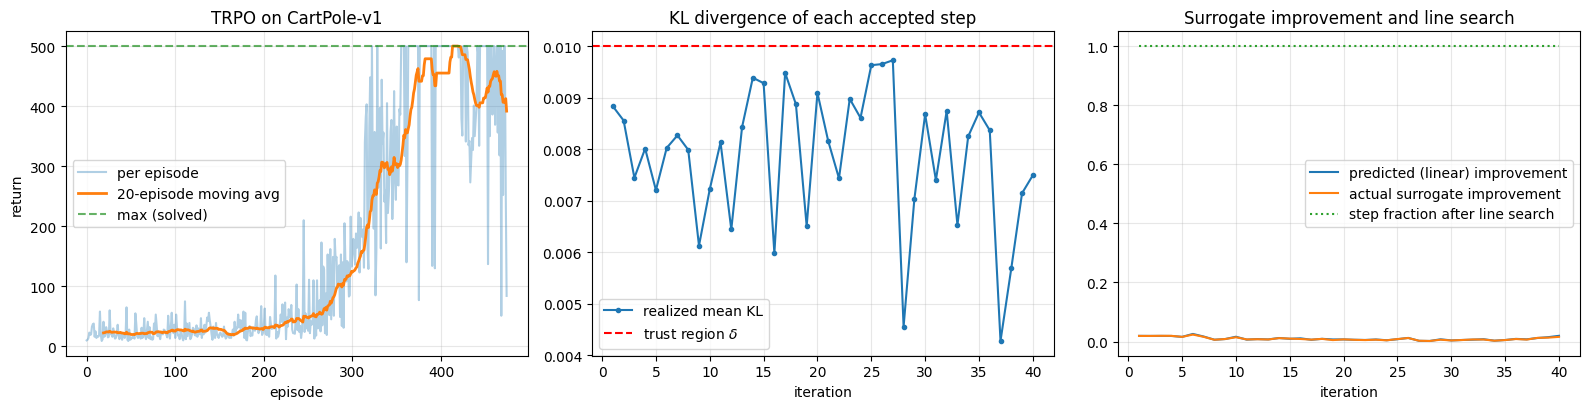

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(ep_returns, alpha=0.35, label="per episode")
axes[0].plot(np.arange(len(ep_returns))[19:], moving_average(ep_returns, 20), lw=2, label="20-episode moving avg")
axes[0].axhline(500, color="green", ls="--", alpha=0.6, label="max (solved)")
axes[0].set_xlabel("episode"); axes[0].set_ylabel("return"); axes[0].set_title("TRPO on CartPole-v1"); axes[0].legend(); axes[0].grid(alpha=0.3)

its = [l["iteration"] for l in logs]
axes[1].plot(its, [l["kl"] for l in logs], "o-", ms=3, label="realized mean KL")
axes[1].axhline(cfg.max_kl, color="red", ls="--", label=r"trust region $\delta$")
axes[1].set_xlabel("iteration"); axes[1].set_title("KL divergence of each accepted step"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(its, [l["expected_improve"] for l in logs], label="predicted (linear) improvement")
axes[2].plot(its, [l["improve"] for l in logs], label="actual surrogate improvement")
axes[2].plot(its, [l["step_frac"] for l in logs], ":", label="step fraction after line search")
axes[2].set_xlabel("iteration"); axes[2].set_title("Surrogate improvement and line search"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.**

- *Middle:* every accepted update lands just below the trust-region boundary $\delta = 0.01$ — the algorithm takes
  (nearly) the largest allowed step, every time, with no learning rate to tune. The realized KL is a bit smaller than
  $\delta$ because the damping term $\lambda I$ makes the curvature estimate slightly pessimistic. Compare with PPO,
  whose approximate KL wanders freely.
- *Right:* the linear model predicts the surrogate improvement well when the step is small; when the actual improvement
  falls below the prediction the line search backs off (step fraction $< 1$). Rejected iterations (if any) show as zero.

### 6.1 Evaluating the trained policy

In [12]:
def act_greedy(obs):
    with torch.no_grad():
        return int(policy.net(torch.as_tensor(obs, dtype=torch.float32, device=device)).argmax().item())

eval_env = gym.make(cfg.env_id); rets = []
for i in range(10):
    o, _ = eval_env.reset(seed=900 + i); done, R = False, 0.0
    while not done:
        o, r, term, trunc, _ = eval_env.step(act_greedy(o)); R += r; done = term or trunc
    rets.append(R)
print(f"Greedy evaluation over 10 episodes: mean {np.mean(rets):.1f}, min {np.min(rets):.0f}, max {np.max(rets):.0f}")

Greedy evaluation over 10 episodes: mean 500.0, min 500, max 500


## 7. Visual Demonstration

Recorded episode: return 500, length 500


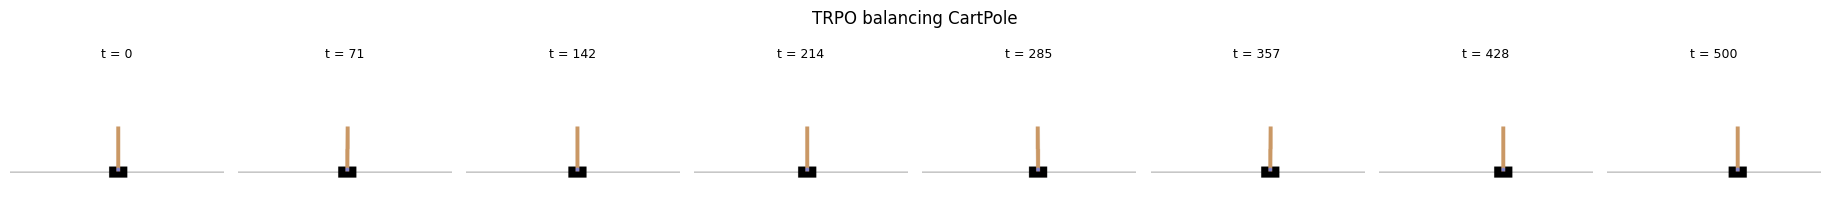

In [13]:
render_env = gym.make(cfg.env_id, render_mode="rgb_array")
frames, ep_ret, ep_len = record_episode(render_env, act_greedy, seed=5, max_steps=500)
render_env.close()
print(f"Recorded episode: return {ep_ret:.0f}, length {ep_len}")
show_filmstrip(frames, n=8, title="TRPO balancing CartPole")

Saved media/trpo_cartpole.gif  (167 frames, 0.03 MB)


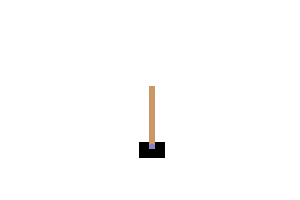

In [14]:
save_gif(frames, "trpo_cartpole", fps=30)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Monotonic improvement in theory, stability in practice.** The trust region removes the learning-rate cliff that
  plagued earlier policy gradients; the same $\delta$ works across very different tasks.
- **Parameterization-invariant steps.** The natural gradient measures distance in policy space, so the update does
  not depend on how the network happens to be parameterized.
- **Principled.** Every component (surrogate, KL constraint, CG, line search) follows from an explicit approximation of a
  theorem — a rare thing in deep RL.

### Weaknesses

- **Expensive and complex.** Each iteration needs ~10 Fisher-vector products (each two backward passes) plus a line
  search; the implementation is an order of magnitude more code than PPO's.
- **Incompatible with parameter sharing and noise.** Architectures that share layers between policy and value, or use
  dropout / batch norm, break the clean second-order treatment. This matters a lot for CNN-based agents.
- **One big step per batch.** TRPO cannot easily do minibatch SGD with many epochs, so it uses data less efficiently
  than PPO.
- **Scales poorly to very large networks** (the CG solve becomes the bottleneck), which is why nobody uses TRPO for LLM fine-tuning.

### Connections

- **Natural policy gradient** (Kakade, 2002) is TRPO without the line search and with a fixed step size.
- **PPO** (Schulman et al., 2017) keeps the surrogate and the idea of a trust region but enforces it with a clipped
  objective and first-order optimization — "TRPO for people who want to use Adam". Engstrom et al. (2020) showed that
  much of PPO's edge over TRPO comes from code-level optimizations, not the objective.
- **ACKTR** approximates $F^{-1}$ with Kronecker factors instead of CG, making natural gradient steps cheap enough for
  every minibatch.
- **KL-regularized RL / RLHF**: the KL-to-reference penalty in RLHF fine-tuning is the *penalty* form of TRPO's
  constraint (§2.3), now with the reference policy fixed rather than moving.
- **Mirror descent** interpretations (e.g. MDPO) show TRPO/PPO as instances of proximal-point methods with a KL Bregman divergence.

## 9. References

1. **Schulman, J., Levine, S., Moritz, P., Jordan, M., & Abbeel, P.** (2015). *Trust region policy optimization.* ICML. [[pdf]](https://arxiv.org/abs/1502.05477)
2. **Kakade, S., & Langford, J.** (2002). *Approximately optimal approximate reinforcement learning.* ICML.
3. **Kakade, S.** (2002). *A natural policy gradient.* NeurIPS.
4. **Amari, S.** (1998). *Natural gradient works efficiently in learning.* Neural Computation, 10(2).
5. **Schulman, J., Moritz, P., Levine, S., Jordan, M., & Abbeel, P.** (2016). *High-dimensional continuous control using generalized advantage estimation.* ICLR.
6. **Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O.** (2017). *Proximal policy optimization algorithms.* arXiv:1707.06347.
7. **Wu, Y., et al.** (2017). *Scalable trust-region method for deep reinforcement learning using Kronecker-factored approximation.* NeurIPS (ACKTR).
8. **Engstrom, L., et al.** (2020). *Implementation matters in deep RL: A case study on PPO and TRPO.* ICLR.
9. **Achiam, J.** (2018). *Spinning Up in Deep RL — Trust Region Policy Optimization.* [[docs]](https://spinningup.openai.com/en/latest/algorithms/trpo.html)